In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [5]:
filename = '/home/lacrio/DATA/term_cal/res_new_700_sergi_075deg/era5_t_uvw_20200205_20200215_thermo.nc'
ds = xr.open_dataset(filename)

In [6]:
import numpy as np
import pandas as pd

def thermo_weighted_table(
    ds,
    lat_min=-70, lat_max=-62,
    lon_min=-76, lon_max=-55
):
    """
    Compute area-weighted thermodynamic budget over a region
    and return a pandas DataFrame.
    """

    # --------------------------------------------
    # COORDENADAS
    # --------------------------------------------
    lons = ds['longitude'].values
    lats = ds['latitude'].values
    times = ds['time'].values

    lon2d, lat2d = np.meshgrid(lons, lats)

    # --------------------------------------------
    # PESOS (cos(lat))
    # --------------------------------------------
    weights = np.sqrt(np.cos(np.deg2rad(lat2d)))

    # --------------------------------------------
    # MÁSCARA ESPACIAL
    # --------------------------------------------
    mask = (
        (lat2d >= lat_min) & (lat2d <= lat_max) &
        (lon2d >= lon_min) & (lon2d <= lon_max)
    )

    weights_masked = np.where(mask, weights, 0)

    # normalización (muy importante)
    wsum = np.sum(weights_masked)

    # --------------------------------------------
    # VARIABLES
    # --------------------------------------------
    Adv  = ds['adv_h'].values
    VAdv = ds['adv_v'].values
    Res  = ds['residual'].values
    Tend = ds['tendency'].values
    T    = ds['t700'].values

    # --------------------------------------------
    # PROMEDIOS ESPACIALES
    # --------------------------------------------
    def wmean(var):
        return np.sum(var * weights_masked, axis=(1,2)) / wsum

    Adv_m  = wmean(Adv)
    VAdv_m = wmean(VAdv)
    Res_m  = wmean(Res)
    Tend_m = wmean(Tend)
    T_m    = wmean(T)

    # --------------------------------------------
    # DATAFRAME (TABLA)
    # --------------------------------------------
    df = pd.DataFrame({
        "time": times,
        "tendency": Tend_m,
        "adv_h": Adv_m,
        "adv_v": VAdv_m,
        "residual": Res_m,
        "t700": T_m
    })

    df = df.set_index("time")

    return df


In [7]:
df_PIs = thermo_weighted_table(ds, lat_min=-52.5, lat_max=-45, lon_min=-74.5, lon_max=-72)
df_APIS = thermo_weighted_table(ds, lat_min=-70, lat_max=-62, lon_min=-76, lon_max=-55)

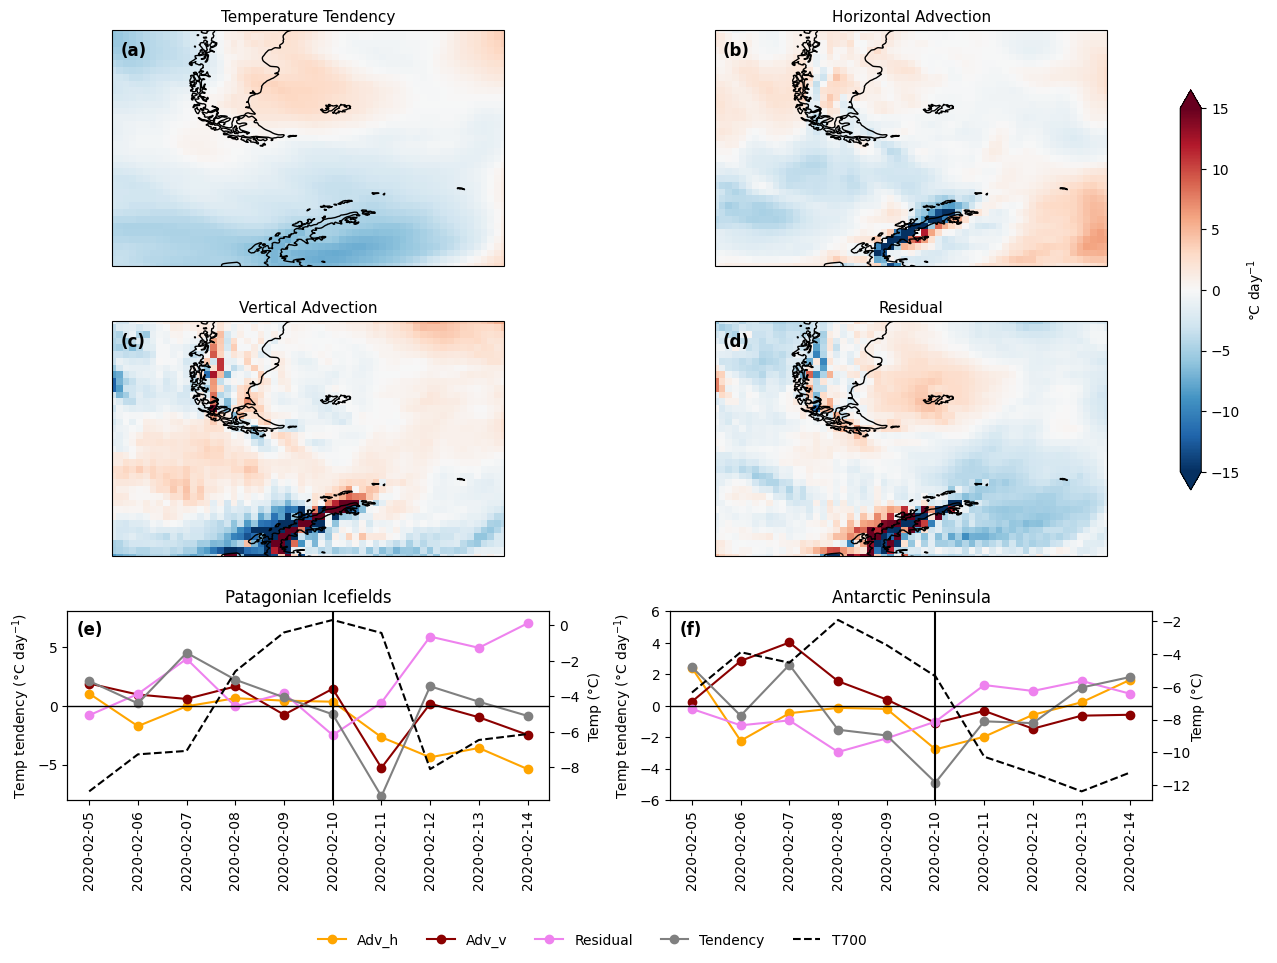

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec

# ============================================
# SELECT TIME
# ============================================
time_sel = '2020-02-10'
ds_sel = ds.sel(time=time_sel)

event_date = np.datetime64("2020-02-10")

# ============================================
# FIGURE + GRID (BALANCED)
# ============================================
fig = plt.figure(figsize=(14, 10))

gs = gridspec.GridSpec(
    3, 2,
    height_ratios=[1, 1, 0.8],   # 🔥 mejor proporción
    hspace=0.25,
    wspace=0.25
)

plt.subplots_adjust(right=0.9)  # espacio para colorbar

# ============================================
# MAPS (a–d)
# ============================================
axes_map = [
    fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[0,1], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1,0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1,1], projection=ccrs.PlateCarree()),
]

vars_plot = ["tendency", "adv_h", "adv_v", "residual"]

titles = [
    "Temperature Tendency",
    "Horizontal Advection",
    "Vertical Advection",
    "Residual"
]

lon = ds_sel.longitude
lat = ds_sel.latitude

vmax = 15
vmin = -vmax

for i, ax in enumerate(axes_map):

    im = ax.pcolormesh(
        lon,
        lat,
        ds_sel[vars_plot[i]],
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        shading="auto",
        transform=ccrs.PlateCarree()
    )

    ax.coastlines(resolution="50m")

    ax.set_extent([
        float(lon.min()), float(lon.max()),
        float(lat.min())+1.5, float(lat.max())
    ])

    ax.set_title(titles[i], fontsize=11)

    ax.text(
        0.02, 0.95,
        f"({chr(97+i)})",
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top"
    )

# ============================================
# COLORBAR (INDEPENDENT)
# ============================================
cax = fig.add_axes([0.92, 0.42, 0.015, 0.4])

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation='vertical',
    extend='both'
)

cbar.set_label("°C day$^{-1}$")

# ============================================
# TIME SERIES (e–f)
# ============================================

# --- Patagonia ---
ax1 = fig.add_subplot(gs[2, 0])
ax1b = ax1.twinx()

t = df_PIs.index

l1, = ax1.plot(t, df_PIs["adv_h"], 'o-', color='orange')
l2, = ax1.plot(t, df_PIs["adv_v"], 'o-', color='darkred')
l3, = ax1.plot(t, df_PIs["residual"], 'o-', color='violet')
l4, = ax1.plot(t, df_PIs["tendency"], 'o-', color='gray')
l5, = ax1b.plot(t, df_PIs["t700"], '--', color='k')

ax1.axhline(0, color='k', linewidth=1)
ax1.axvline(event_date, color='k', linestyle='-')

ax1.set_ylim(-8, 8)
ax1.set_title("Patagonian Icefields")

ax1.set_ylabel('Temp tendency (°C day$^{-1}$)')
ax1b.set_ylabel('Temp (°C)')

# mover eje derecho
ax1b.yaxis.set_label_coords(1.08, 0.5)

ax1.text(0.02, 0.95, "(e)", transform=ax1.transAxes,
         fontsize=12, fontweight="bold", va="top")


# --- Antarctic Peninsula ---
ax2 = fig.add_subplot(gs[2, 1])
ax2b = ax2.twinx()

t = df_APIS.index

ax2.plot(t, df_APIS["adv_h"], 'o-', color='orange')
ax2.plot(t, df_APIS["adv_v"], 'o-', color='darkred')
ax2.plot(t, df_APIS["residual"], 'o-', color='violet')
ax2.plot(t, df_APIS["tendency"], 'o-', color='gray')
ax2b.plot(t, df_APIS["t700"], '--', color='k')

ax2.axhline(0, color='k', linewidth=1)
ax2.axvline(event_date, color='k', linestyle='-')

ax2.set_ylim(-6, 6)
ax2.set_title("Antarctic Peninsula")

# evitar duplicación
ax2.set_ylabel('Temp tendency (°C day$^{-1}$)')
ax2b.set_ylabel('Temp (°C)')
ax2b.yaxis.set_label_coords(1.08, 0.5)

ax2.text(0.02, 0.95, "(f)", transform=ax2.transAxes,
         fontsize=12, fontweight="bold", va="top")

# ============================================
# LEGEND (SOLO TIME SERIES, CENTRADA)
# ============================================
fig.legend(
    [l1, l2, l3, l4, l5],
    ['Adv_h', 'Adv_v', 'Residual', 'Tendency', 'T700'],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=5,
    frameon=False,
    fontsize=10
)

# ============================================
# FORMAT
# ============================================
for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=90)

fig.savefig(
    "./fig/temp_tendency_sergi_2020_075deg.png",
    dpi=300,
    bbox_inches="tight"
)


In [9]:
import os


In [10]:
base_dir    = "/home/lacrio/DATA/term_cal/res_new_700_sergi_075deg"
csv_days    = "/home/lacrio/DATA/term_cal/range_date_evets.csv"
nc_pattern  = "era5_t_uvw_{start}_{end}_thermo.nc"


In [11]:
def load_event(row, i):

    start = pd.to_datetime(row["start_date"])
    end   = pd.to_datetime(row["end_date"])
    central = pd.to_datetime(row["event_date"])

    path = os.path.join(
        base_dir,
        nc_pattern.format(
            start=start.strftime("%Y%m%d"),
            end=end.strftime("%Y%m%d")
        )
    )
    ds = xr.open_dataset(path).sel(time=central)
    return ds

def load_ds(row, i):

    start = pd.to_datetime(row["start_date"])
    end   = pd.to_datetime(row["end_date"])

    path = os.path.join(
        base_dir,
        nc_pattern.format(
            start=start.strftime("%Y%m%d"),
            end=end.strftime("%Y%m%d")
        )
    )
    ds = xr.open_dataset(path)
    return ds


In [12]:
df = pd.read_csv(csv_days)#[0:20]
df

,start_date,event_date,end_date
0,1980-02-12,1980-02-17,1980-02-22
1,1980-12-18,1980-12-23,1980-12-28
2,1981-01-21,1981-01-26,1981-01-31
3,1981-12-04,1981-12-09,1981-12-14
4,1982-02-25,1982-03-02,1982-03-07
...,...,...,...
95,2021-11-04,2021-11-09,2021-11-14
96,2021-12-03,2021-12-08,2021-12-13
97,2021-12-14,2021-12-19,2021-12-24
98,2022-02-02,2022-02-07,2022-02-12


In [13]:
datasets_event = []

for i, row in df.iterrows():

    ds_evt = load_event(row, i)

    datasets_event.append(ds_evt)


In [14]:
def make_relative_time(df_event, event_date):
    """
    Convierte el índice temporal a días relativos al evento
    """
    df_rel = df_event.copy()

    # asegurar datetime
    df_rel.index = np.array(df_rel.index, dtype='datetime64[ns]')
    event_date = np.datetime64(event_date)

    # tiempo relativo en días
    rel_time = (df_rel.index - event_date) / np.timedelta64(1, 'D')

    df_rel.index = rel_time.astype(int)

    return df_rel

In [15]:
df_PIs_list = []
df_APIS_list = []

for i, row in df.iterrows():

    ds_ev = load_ds(row, i)

    df_PIs = thermo_weighted_table(
        ds_ev,
        lat_min=-52.5, lat_max=-45,
        lon_min=-74.5, lon_max=-72
    )

    df_APIS = thermo_weighted_table(
        ds_ev,
        lat_min=-70, lat_max=-62,
        lon_min=-76, lon_max=-55
    )

    # 🔥 convertir a tiempo relativo
    df_PIs = make_relative_time(df_PIs, row["event_date"])
    df_APIS = make_relative_time(df_APIS, row["event_date"])

    df_PIs_list.append(df_PIs)
    df_APIS_list.append(df_APIS)

In [16]:
df_PIs_comp = pd.concat(df_PIs_list).groupby(level=0).mean()
df_APIS_comp = pd.concat(df_APIS_list).groupby(level=0).mean()
ds_comp = xr.concat(datasets_event, dim='time').mean('time')

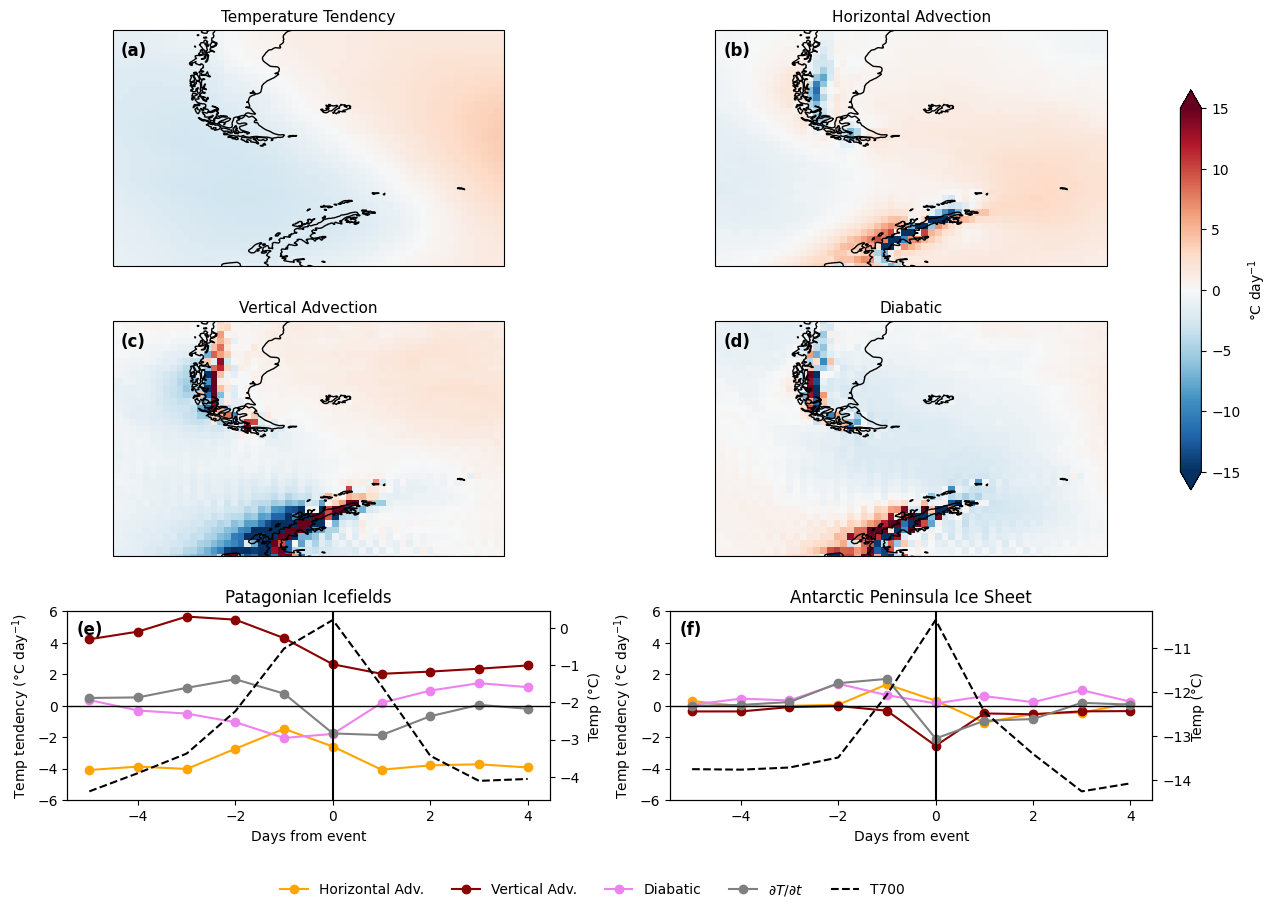

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec

# ============================================
# SELECT COMPOSITE TIME (0 = EVENT DAY)
# ============================================
time_sel = 0   # 🔥 clave: tiempo relativo
ds_sel = ds_comp#.sel(time=time_sel)

# ============================================
# FIGURE + GRID
# ============================================
fig = plt.figure(figsize=(14, 10))

gs = gridspec.GridSpec(
    3, 2,
    height_ratios=[1, 1, 0.8],
    hspace=0.25,
    wspace=0.25
)

plt.subplots_adjust(right=0.9)

# ============================================
# MAPS (a–d)
# ============================================
axes_map = [
    fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[0,1], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1,0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1,1], projection=ccrs.PlateCarree()),
]

vars_plot = ["tendency", "adv_h", "adv_v", "residual"]

titles = [
    "Temperature Tendency",
    "Horizontal Advection",
    "Vertical Advection",
    "Diabatic"
]

lon = ds_sel.longitude
lat = ds_sel.latitude

vmax = 15
vmin = -vmax

for i, ax in enumerate(axes_map):

    im = ax.pcolormesh(
        lon,
        lat,
        ds_sel[vars_plot[i]],
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        shading="auto",
        transform=ccrs.PlateCarree()
    )

    ax.coastlines(resolution="50m")

    ax.set_extent([
        float(lon.min()), float(lon.max()),
        float(lat.min())+1.5, float(lat.max())
    ])

    ax.set_title(titles[i], fontsize=11)

    ax.text(
        0.02, 0.95,
        f"({chr(97+i)})",
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top"
    )

# ============================================
# COLORBAR
# ============================================
cax = fig.add_axes([0.92, 0.42, 0.015, 0.4])

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation='vertical',
    extend='both'
)

cbar.set_label("°C day$^{-1}$")

# ============================================
# TIME SERIES (RELATIVE TIME)
# ============================================

# --- Patagonia ---
ax1 = fig.add_subplot(gs[2, 0])
ax1b = ax1.twinx()

t = df_PIs_comp.index  # 🔥 tiempo relativo

l1, = ax1.plot(t, df_PIs_comp["adv_h"], 'o-', color='orange')
l2, = ax1.plot(t, df_PIs_comp["adv_v"], 'o-', color='darkred')
l3, = ax1.plot(t, df_PIs_comp["residual"], 'o-', color='violet')
l4, = ax1.plot(t, df_PIs_comp["tendency"], 'o-', color='gray')
l5, = ax1b.plot(t, df_PIs_comp["t700"], '--', color='k')

# 🔥 EVENT DAY = 0
ax1.axvline(0, color='k', linestyle='-')
ax1.axhline(0, color='k', linewidth=1)

ax1.set_ylim(-6, 6)
ax1.set_title("Patagonian Icefields")

ax1.set_ylabel('Temp tendency (°C day$^{-1}$)')
ax1b.set_ylabel('Temp (°C)')
ax1b.yaxis.set_label_coords(1.08, 0.5)

ax1.text(0.02, 0.95, "(e)", transform=ax1.transAxes,
         fontsize=12, fontweight="bold", va="top")


# --- Antarctic Peninsula ---
ax2 = fig.add_subplot(gs[2, 1])
ax2b = ax2.twinx()

t = df_APIS_comp.index

ax2.plot(t, df_APIS_comp["adv_h"], 'o-', color='orange')
ax2.plot(t, df_APIS_comp["adv_v"], 'o-', color='darkred')
ax2.plot(t, df_APIS_comp["residual"], 'o-', color='violet')
ax2.plot(t, df_APIS_comp["tendency"], 'o-', color='gray')
ax2b.plot(t, df_APIS_comp["t700"], '--', color='k')

ax2.axvline(0, color='k', linestyle='-')
ax2.axhline(0, color='k', linewidth=1)

ax2.set_ylim(-6, 6)
ax2.set_title("Antarctic Peninsula Ice Sheet")

ax2.set_ylabel('Temp tendency (°C day$^{-1}$)')
ax2b.set_ylabel('Temp (°C)')
ax2b.yaxis.set_label_coords(1.08, 0.5)

ax2.text(0.02, 0.95, "(f)", transform=ax2.transAxes,
         fontsize=12, fontweight="bold", va="top")

# ============================================
# LEGEND
# ============================================
fig.legend(
    [l1, l2, l3, l4, l5],
    ["Horizontal Adv.", "Vertical Adv.", "Diabatic", r"$\partial T / \partial t$", "T700"],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.0),
    ncol=5,
    frameon=False,
    fontsize=10
)

# ============================================
# FORMAT
# ============================================
for ax in [ax1, ax2]:
    ax.set_xlabel("Days from event")
    ax.tick_params(axis='x', rotation=0)

# ============================================
# SAVE
# ============================================
fig.savefig(
    "./fig/temp_tendency_composite_075deg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
df_PIs_comp.round(2)

,tendency,adv_h,adv_v,residual,t700
-5,0.49,-4.09,4.22,0.36,-4.39
-4,0.52,-3.88,4.71,-0.31,-3.90
-3,1.14,-4.03,5.67,-0.51,-3.37
-2,1.68,-2.74,5.47,-1.05,-2.24
-1,0.77,-1.47,4.30,-2.06,-0.56
0,-1.77,-2.60,2.63,-1.80,0.21
1,-1.87,-4.08,2.03,0.18,-1.56
2,-0.67,-3.80,2.17,0.96,-3.43
3,0.05,-3.73,2.35,1.43,-4.11
4,-0.20,-3.93,2.56,1.18,-4.06


In [19]:
df_APIS_comp.round(2)

,tendency,adv_h,adv_v,residual,t700
-5,-0.01,0.30,-0.37,0.06,-13.76
-4,0.05,-0.03,-0.37,0.45,-13.77
-3,0.23,-0.01,-0.09,0.33,-13.72
-2,1.43,0.06,-0.02,1.39,-13.49
-1,1.70,1.35,-0.32,0.67,-12.06
0,-2.09,0.32,-2.55,0.14,-10.36
1,-0.96,-1.07,-0.50,0.61,-12.45
2,-0.85,-0.53,-0.55,0.22,-13.41
3,0.18,-0.44,-0.36,0.99,-14.26
4,0.07,0.16,-0.35,0.26,-14.08


In [20]:
from shapely.geometry import Point
from shapely.prepared import prep
from cartopy.io.shapereader import Reader as ShapeReader
import cartopy.feature as cfeature

In [21]:
# =====================================================
# MASK FUNCTION (UNCHANGED LOGIC)
# =====================================================
def mask_with_shapefile(ds, shp_path):

    geoms = [geom.simplify(0.05)
             for geom in ShapeReader(shp_path).geometries()]
    geoms = [prep(geom) for geom in geoms]

    lon = ds.longitude.values
    lat = ds.latitude.values

    lon2d, lat2d = np.meshgrid(lon, lat)
    mask = np.zeros(lon2d.shape, dtype=bool)

    print("🔹 Creating shapefile mask...")

    for i in range(lat2d.shape[0]):
        for j in range(lat2d.shape[1]):
            pt = Point(lon2d[i, j], lat2d[i, j])
            inside = any(geom.contains(pt) for geom in geoms)
            mask[i, j] = not inside

    print("✅ Mask ready")
    return mask


# =====================================================
# PATAGONIA ICEFIELD (SHAPEFILE MASK + WEIGHTS)
# =====================================================
shp_path = "/home/lacrio/Patagonia-Antarctic_Peninsula/data/shp/Glaciers_NPI_SPI.shp"

mask_PI = mask_with_shapefile(ds_comp, shp_path)

mask_PI_da = xr.DataArray(
    mask_PI,
    coords={"latitude": ds_comp.latitude, "longitude": ds_comp.longitude},
    dims=("latitude", "longitude")
)


# =====================================================
# ANTARCTIC PENINSULA (LAND MASK + WEIGHTS)
# =====================================================
land_feature = cfeature.NaturalEarthFeature("physical", "land", "10m")
land_geom = [prep(geom) for geom in land_feature.geometries()]

lon2d, lat2d = np.meshgrid(ds_comp.longitude.values,
                           ds_comp.latitude.values)

mask_AP = np.zeros(lon2d.shape, dtype=bool)

print("🔹 Creating AP mask...")

for i in range(lon2d.shape[0]):
    for j in range(lon2d.shape[1]):
        pt = Point(lon2d[i, j], lat2d[i, j])
        if not any(geom.contains(pt) for geom in land_geom):
            mask_AP[i, j] = True

# limitar región
mask_AP[(lat2d < -68) | (lat2d > -60)] = True

print("✅ AP mask ready")

mask_AP_da = xr.DataArray(
    mask_AP,
    coords={"latitude": ds_comp.latitude, "longitude": ds_comp.longitude},
    dims=("latitude", "longitude")
)


🔹 Creating shapefile mask...
✅ Mask ready
🔹 Creating AP mask...
✅ AP mask ready


In [22]:
def thermo_weighted_table(
    ds,
    mask_da=None   # 🔥 nueva opción
):
    """
    Compute area-weighted thermodynamic budget.
    mask_da: xr.DataArray (lat, lon) with True = masked
    """

    # --------------------------------------------
    # COORDENADAS
    # --------------------------------------------
    lons = ds['longitude'].values
    lats = ds['latitude'].values
    times = ds['time'].values

    lon2d, lat2d = np.meshgrid(lons, lats)

    # --------------------------------------------
    # PESOS
    # --------------------------------------------
    weights = np.sqrt(np.cos(np.deg2rad(lat2d)))

    # --------------------------------------------
    # 🔥 USAR SHAPEFILE MASK SI EXISTE
    # --------------------------------------------
    if mask_da is not None:
        mask = mask_da.values   # True = fuera
        weights_masked = np.where(~mask, weights, 0)
    else:
        raise ValueError("You must provide a mask (e.g., shapefile mask)")

    # normalización
    wsum = np.sum(weights_masked)

    # --------------------------------------------
    # VARIABLES
    # --------------------------------------------
    Adv  = ds['adv_h'].values
    VAdv = ds['adv_v'].values
    Res  = ds['residual'].values
    Tend = ds['tendency'].values
    T    = ds['t700'].values

    # --------------------------------------------
    # PROMEDIO
    # --------------------------------------------
    def wmean(var):
        return np.sum(var * weights_masked, axis=(1,2)) / wsum

    df = pd.DataFrame({
        "time": times,
        "tendency": wmean(Tend),
        "adv_h": wmean(Adv),
        "adv_v": wmean(VAdv),
        "residual": wmean(Res),
        "t700": wmean(T)
    })

    return df.set_index("time")

In [23]:
df_PIs_list = []
df_APIS_list = []

for i, row in df.iterrows():

    ds_ev = load_ds(row, i)

    df_PIs = thermo_weighted_table(ds_ev, mask_da=mask_PI_da)

    df_APIS = thermo_weighted_table(ds_ev, mask_da=mask_AP_da)

    # 🔥 convertir a tiempo relativo
    df_PIs = make_relative_time(df_PIs, row["event_date"])
    df_APIS = make_relative_time(df_APIS, row["event_date"])

    df_PIs_list.append(df_PIs)
    df_APIS_list.append(df_APIS)

In [24]:
df_PIs_comp = pd.concat(df_PIs_list).groupby(level=0).mean()
df_APIS_comp = pd.concat(df_APIS_list).groupby(level=0).mean()
ds_comp = xr.concat(datasets_event, dim='time').mean('time')

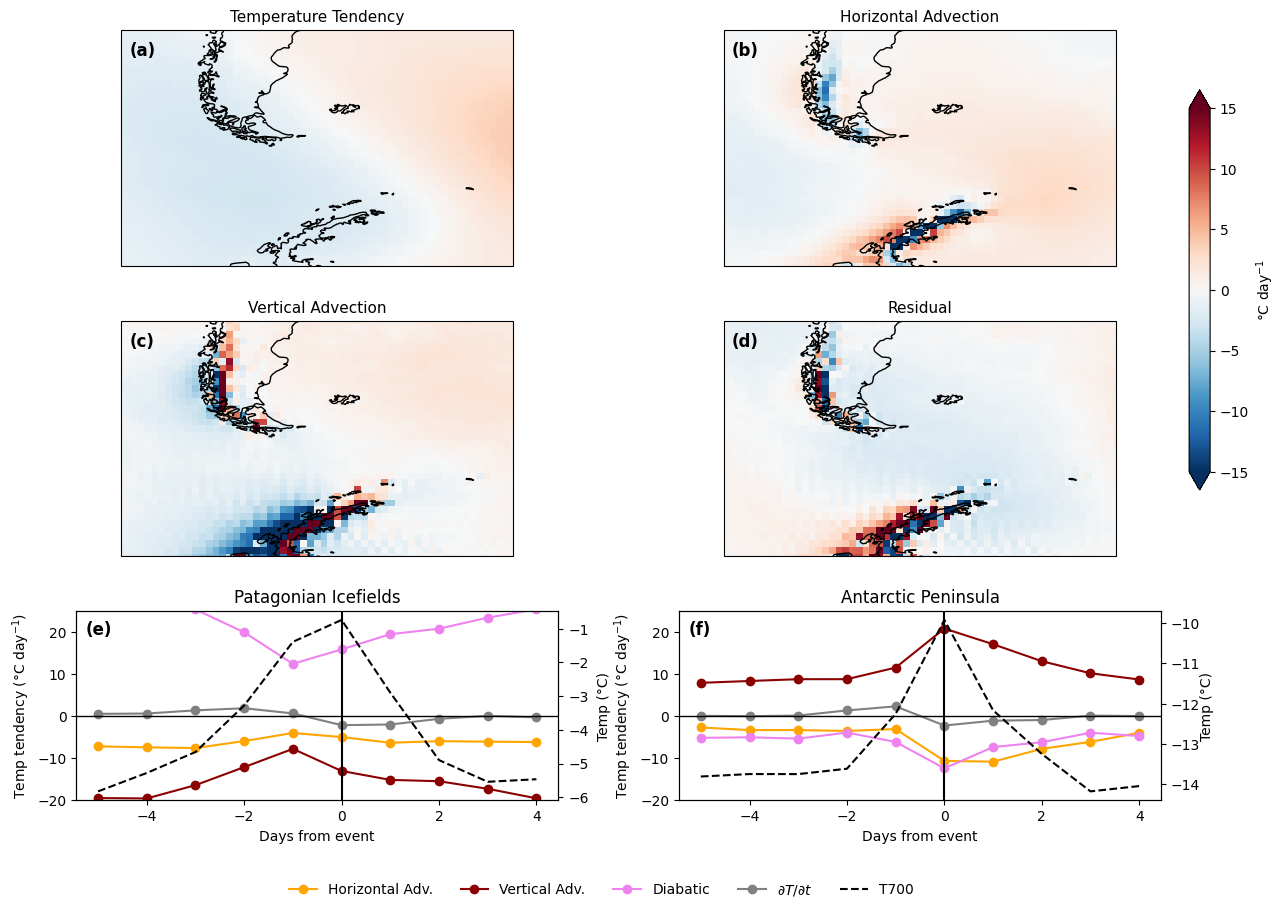

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec

# ============================================
# SELECT COMPOSITE TIME (0 = EVENT DAY)
# ============================================
time_sel = 0   # 🔥 clave: tiempo relativo
ds_sel = ds_comp#.sel(time=time_sel)

# ============================================
# FIGURE + GRID
# ============================================
fig = plt.figure(figsize=(14, 10))

gs = gridspec.GridSpec(
    3, 2,
    height_ratios=[1, 1, 0.8],
    hspace=0.25,
    wspace=0.25
)

plt.subplots_adjust(right=0.9)

# ============================================
# MAPS (a–d)
# ============================================
axes_map = [
    fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[0,1], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1,0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1,1], projection=ccrs.PlateCarree()),
]

vars_plot = ["tendency", "adv_h", "adv_v", "residual"]

titles = [
    "Temperature Tendency",
    "Horizontal Advection",
    "Vertical Advection",
    "Residual"
]

lon = ds_sel.longitude
lat = ds_sel.latitude

vmax = 15
vmin = -vmax

for i, ax in enumerate(axes_map):

    im = ax.pcolormesh(
        lon,
        lat,
        ds_sel[vars_plot[i]],
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        shading="auto",
        transform=ccrs.PlateCarree()
    )

    ax.coastlines(resolution="50m")

    ax.set_extent([
        float(lon.min()), float(lon.max()),
        float(lat.min())+1.5, float(lat.max())
    ])

    ax.set_title(titles[i], fontsize=11)

    ax.text(
        0.02, 0.95,
        f"({chr(97+i)})",
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top"
    )

# ============================================
# COLORBAR
# ============================================
cax = fig.add_axes([0.92, 0.42, 0.015, 0.4])

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation='vertical',
    extend='both'
)

cbar.set_label("°C day$^{-1}$")

# ============================================
# TIME SERIES (RELATIVE TIME)
# ============================================

# --- Patagonia ---
ax1 = fig.add_subplot(gs[2, 0])
ax1b = ax1.twinx()

t = df_PIs_comp.index  # 🔥 tiempo relativo

l1, = ax1.plot(t, df_PIs_comp["adv_h"], 'o-', color='orange')
l2, = ax1.plot(t, df_PIs_comp["adv_v"], 'o-', color='darkred')
l3, = ax1.plot(t, df_PIs_comp["residual"], 'o-', color='violet')
l4, = ax1.plot(t, df_PIs_comp["tendency"], 'o-', color='gray')
l5, = ax1b.plot(t, df_PIs_comp["t700"], '--', color='k')

# 🔥 EVENT DAY = 0
ax1.axvline(0, color='k', linestyle='-')
ax1.axhline(0, color='k', linewidth=1)

ax1.set_ylim(-20, 25)
ax1.set_title("Patagonian Icefields")

ax1.set_ylabel('Temp tendency (°C day$^{-1}$)')
ax1b.set_ylabel('Temp (°C)')
ax1b.yaxis.set_label_coords(1.08, 0.5)

ax1.text(0.02, 0.95, "(e)", transform=ax1.transAxes,
         fontsize=12, fontweight="bold", va="top")


# --- Antarctic Peninsula ---
ax2 = fig.add_subplot(gs[2, 1])
ax2b = ax2.twinx()

t = df_APIS_comp.index

ax2.plot(t, df_APIS_comp["adv_h"], 'o-', color='orange')
ax2.plot(t, df_APIS_comp["adv_v"], 'o-', color='darkred')
ax2.plot(t, df_APIS_comp["residual"], 'o-', color='violet')
ax2.plot(t, df_APIS_comp["tendency"], 'o-', color='gray')
ax2b.plot(t, df_APIS_comp["t700"], '--', color='k')

ax2.axvline(0, color='k', linestyle='-')
ax2.axhline(0, color='k', linewidth=1)

ax2.set_ylim(-20, 25)
ax2.set_title("Antarctic Peninsula")

ax2.set_ylabel('Temp tendency (°C day$^{-1}$)')
ax2b.set_ylabel('Temp (°C)')
ax2b.yaxis.set_label_coords(1.08, 0.5)

ax2.text(0.02, 0.95, "(f)", transform=ax2.transAxes,
         fontsize=12, fontweight="bold", va="top")

# ============================================
# LEGEND
# ============================================
fig.legend(
    [l1, l2, l3, l4, l5],
    ["Horizontal Adv.", "Vertical Adv.", "Diabatic", r"$\partial T / \partial t$", "T700"],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.0),
    ncol=5,
    frameon=False,
    fontsize=10
)

# ============================================
# FORMAT
# ============================================
for ax in [ax1, ax2]:
    ax.set_xlabel("Days from event")
    ax.tick_params(axis='x', rotation=0)

# ============================================
# SAVE
# ============================================
fig.savefig(
    "./fig/temp_tendency_composite_mask_075deg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()